In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_score, recall_score
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the built-in Breast Cancer dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Dataset:", data.DESCR[:300])

Dataset: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of dista


In [4]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (569, 31)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness e

In [6]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing: 0


Class Distribution:
  Malignant (0): 212 samples
  Benign    (1): 357 samples


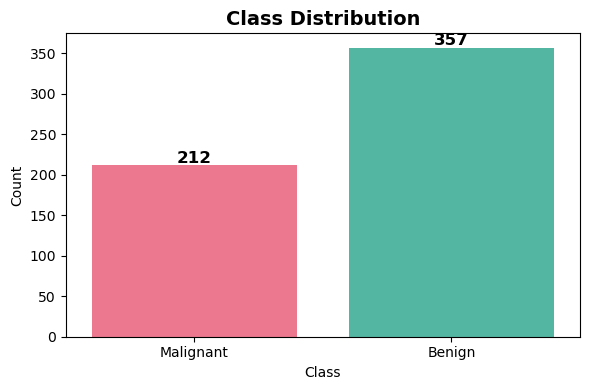

In [8]:
print("Class Distribution:")
print(f"  Malignant (0): {(df['target']==0).sum()} samples")
print(f"  Benign    (1): {(df['target']==1).sum()} samples")

# Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="target", data=df, palette=["#FF6584", "#43C6AC"])
ax.set_xticklabels(["Malignant", "Benign"])
plt.title("Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()+3),
                ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

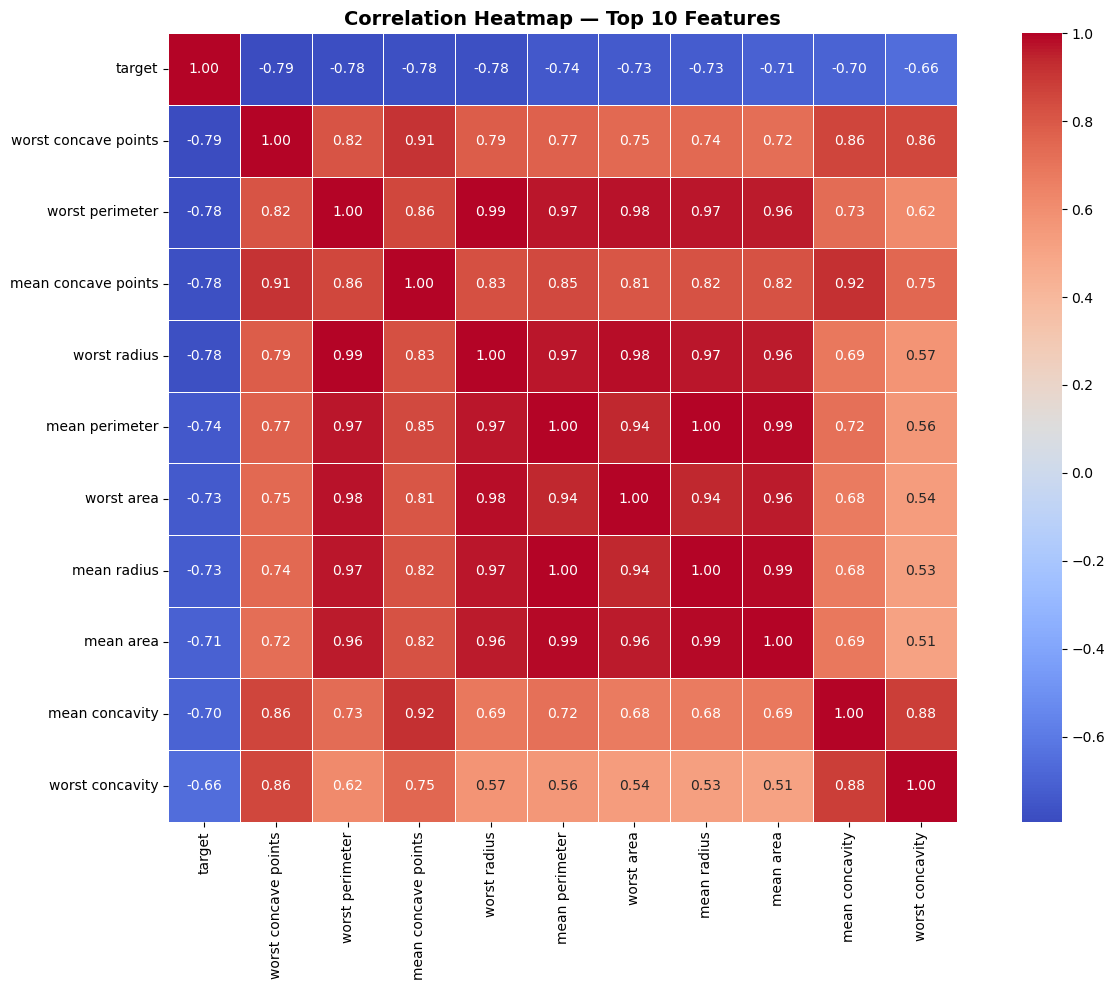

In [9]:
plt.figure(figsize=(14, 10))
top_features = df.corr()["target"].abs().sort_values(ascending=False).index[:11]
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Top 10 Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)

Features shape: (569, 30)
Target shape  : (569,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 455
Testing  samples : 114


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print("Mean (approx 0):", X_train.mean().round(4))
print("Std  (approx 1):", X_train.std().round(4))

✅ Features scaled using StandardScaler
Mean (approx 0): -0.0
Std  (approx 1): 1.0


In [13]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("✅ Logistic Regression trained!")
print(f"   Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

✅ Logistic Regression trained!
   Accuracy: 0.9825


In [14]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("✅ Decision Tree trained!")
print(f"   Accuracy: {accuracy_score(y_test, dt_pred):.4f}")

✅ Decision Tree trained!
   Accuracy: 0.9211


In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest trained!")
print(f"   Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

✅ Random Forest trained!
   Accuracy: 0.9561


In [16]:
models     = {"Logistic Regression": lr_pred,
              "Decision Tree":       dt_pred,
              "Random Forest":       rf_pred}

print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)

for name, pred in models.items():
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    print(f"{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Model                    Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
Logistic Regression        0.9825     0.9861     0.9861     0.9861
Decision Tree              0.9211     0.9565     0.9167     0.9362
Random Forest              0.9561     0.9589     0.9722     0.9655


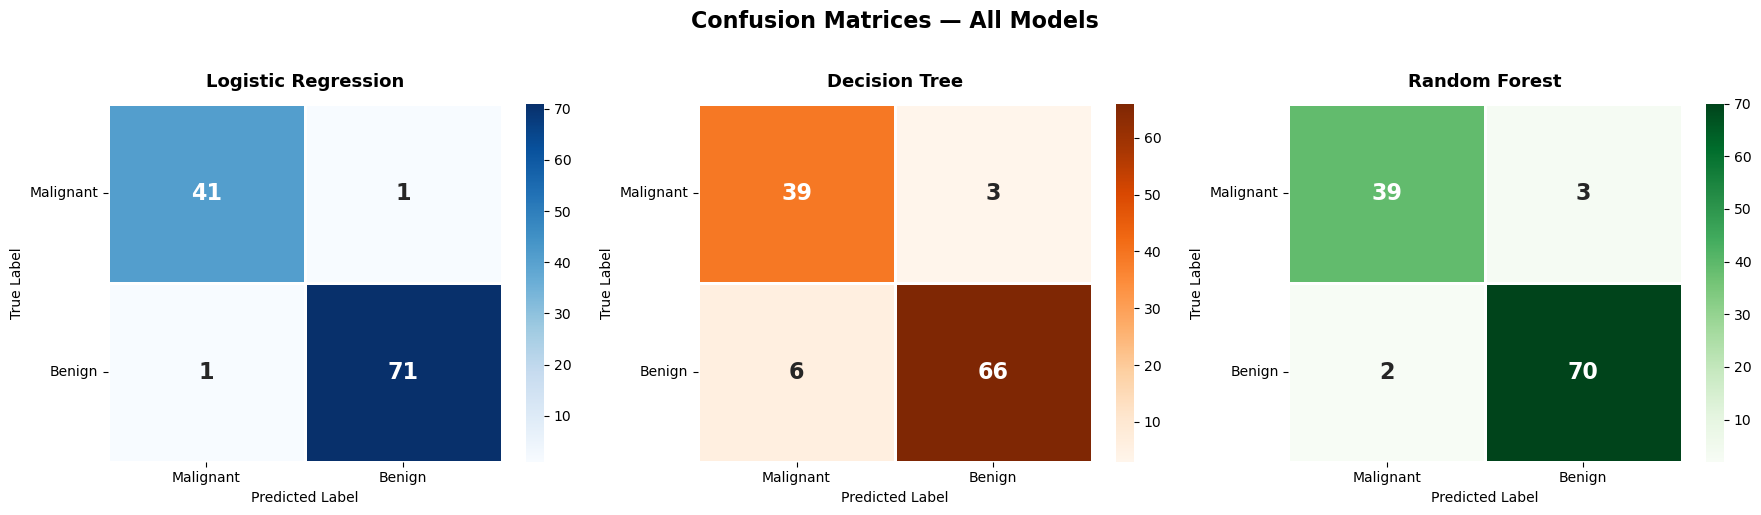

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles  = ["Logistic Regression", "Decision Tree", "Random Forest"]
preds   = [lr_pred, dt_pred, rf_pred]
colors  = ["Blues", "Oranges", "Greens"]

for ax, title, pred, cmap in zip(axes, titles, preds, colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                linewidths=2, annot_kws={"size": 16, "weight": "bold"})
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticklabels(["Malignant", "Benign"])
    ax.set_yticklabels(["Malignant", "Benign"], rotation=0)

plt.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

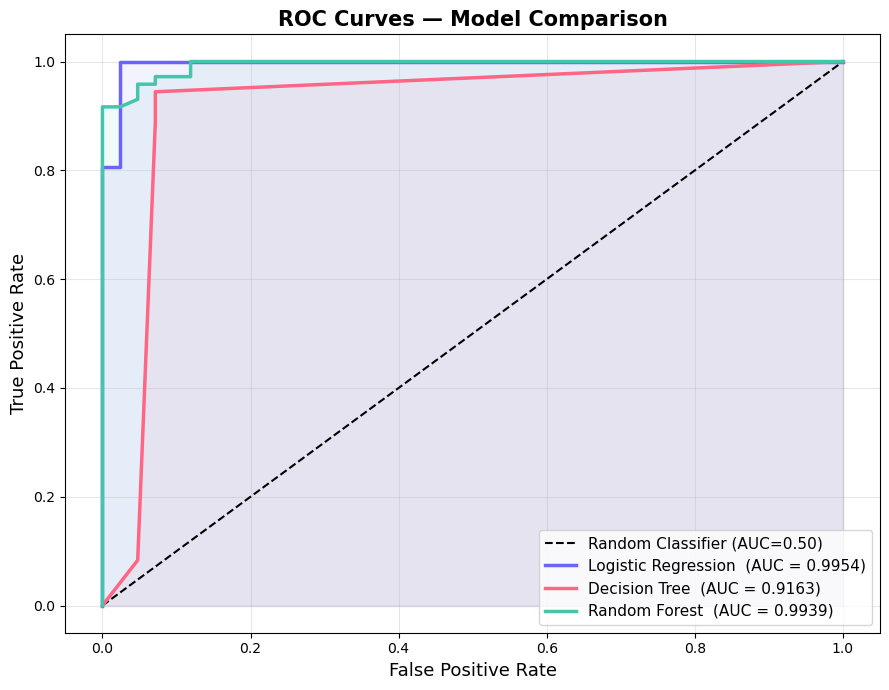

In [18]:
plt.figure(figsize=(9, 7))

model_objs = [lr_model, dt_model, rf_model]
names      = ["Logistic Regression", "Decision Tree", "Random Forest"]
clrs       = ["#6C63FF", "#FF6584", "#43C6AC"]

plt.plot([0,1], [0,1], "k--", lw=1.5, label="Random Classifier (AUC=0.50)")

for model, name, clr in zip(model_objs, names, clrs):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=clr, lw=2.5, label=f"{name}  (AUC = {roc_auc:.4f})")
    plt.fill_between(fpr, tpr, alpha=0.08, color=clr)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curves — Model Comparison", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
print("=" * 50)
print("  CLASSIFICATION REPORT — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, lr_pred,
      target_names=["Malignant", "Benign"]))

  CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



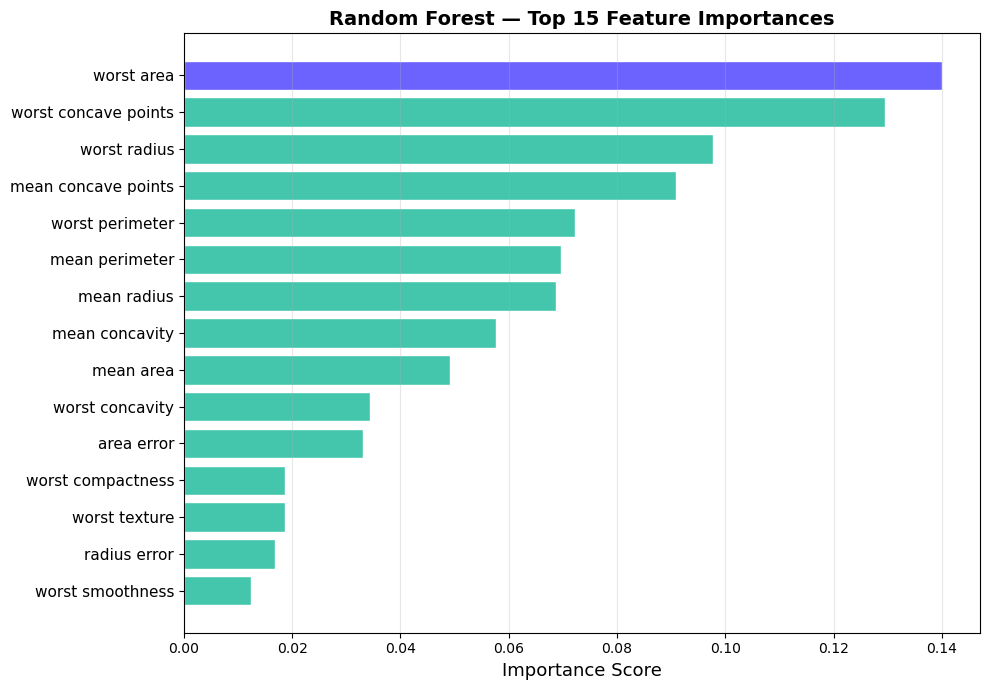

In [20]:
importances = rf_model.feature_importances_
feat_names  = data.feature_names
idx         = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 7))
colors = ["#6C63FF" if i == idx[-1] else "#43C6AC" for i in idx]
plt.barh(range(15), importances[idx], color=colors, edgecolor="white")
plt.yticks(range(15), feat_names[idx], fontsize=11)
plt.xlabel("Importance Score", fontsize=13)
plt.title("Random Forest — Top 15 Feature Importances",
          fontsize=14, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

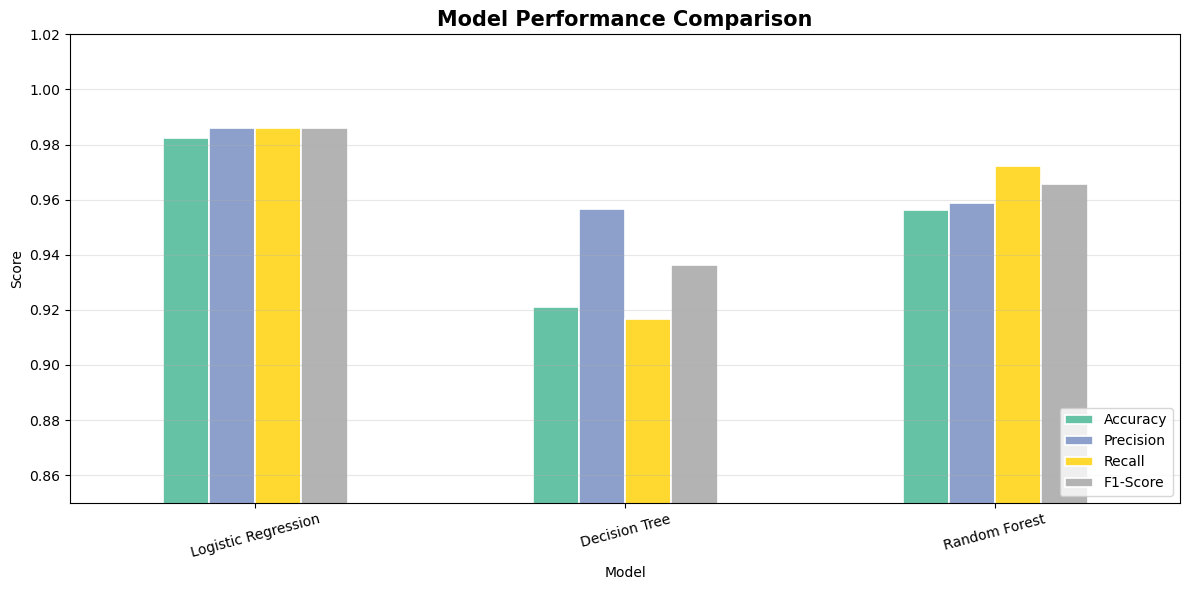

In [21]:
metrics  = {
    "Logistic Regression": [accuracy_score(y_test, lr_pred),
                             precision_score(y_test, lr_pred),
                             recall_score(y_test, lr_pred),
                             f1_score(y_test, lr_pred)],
    "Decision Tree":       [accuracy_score(y_test, dt_pred),
                             precision_score(y_test, dt_pred),
                             recall_score(y_test, dt_pred),
                             f1_score(y_test, dt_pred)],
    "Random Forest":       [accuracy_score(y_test, rf_pred),
                             precision_score(y_test, rf_pred),
                             recall_score(y_test, rf_pred),
                             f1_score(y_test, rf_pred)],
}
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
df_metrics   = pd.DataFrame(metrics, index=metric_names)

df_metrics.T.plot(kind="bar", figsize=(12, 6), colormap="Set2",
                  edgecolor="white", linewidth=1.2)
plt.title("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.85, 1.02)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print("=" * 55)
print("     THIRANEX INTERNSHIP — TASK 2 SUMMARY")
print("=" * 55)
print(f"  Dataset    : Breast Cancer Wisconsin (569 samples)")
print(f"  Features   : 30  |  Classes: Malignant / Benign")
print(f"  Train/Test : 455 / 114  (80/20 split)")
print()
print(f"  📌 Logistic Regression → {accuracy_score(y_test, lr_pred):.2%} accuracy")
print(f"  📌 Decision Tree       → {accuracy_score(y_test, dt_pred):.2%} accuracy")
print(f"  📌 Random Forest       → {accuracy_score(y_test, rf_pred):.2%} accuracy")
print()
best = max([("Logistic Regression", lr_pred),
            ("Decision Tree", dt_pred),
            ("Random Forest", rf_pred)],
           key=lambda x: accuracy_score(y_test, x[1]))
print(f"  🏆 Best Model : {best[0]}  ({accuracy_score(y_test, best[1]):.2%})")
print("=" * 55)
print("  ✅ Task 2 Complete!")
print("=" * 55)

     THIRANEX INTERNSHIP — TASK 2 SUMMARY
  Dataset    : Breast Cancer Wisconsin (569 samples)
  Features   : 30  |  Classes: Malignant / Benign
  Train/Test : 455 / 114  (80/20 split)

  📌 Logistic Regression → 98.25% accuracy
  📌 Decision Tree       → 92.11% accuracy
  📌 Random Forest       → 95.61% accuracy

  🏆 Best Model : Logistic Regression  (98.25%)
  ✅ Task 2 Complete!
